### Author Details

Name: Chidiogo Joyce Ezeugwu

Email: ezeugwuchidiogo@gmail.com


# Olist E-Commerce store

### Exploring the datasets from the store

In [1]:
# First import the libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the datasets
customers = pd.read_csv('/Users/mac/Documents/Data science:analytics projects/Olist Tables/olist_customers_dataset.csv')
location = pd.read_csv('/Users/mac/Documents/Data science:analytics projects/Olist Tables/olist_geolocation_dataset.csv')
order_items = pd.read_csv('/Users/mac/Documents/Data science:analytics projects/Olist Tables/olist_order_items_dataset.csv')
order_payments = pd.read_csv('/Users/mac/Documents/Data science:analytics projects/Olist Tables/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('/Users/mac/Documents/Data science:analytics projects/Olist Tables/olist_order_reviews_dataset.csv')
orders_dataset = pd.read_csv('/Users/mac/Documents/Data science:analytics projects/Olist Tables/olist_orders_dataset.csv')
products_dataset = pd.read_csv('/Users/mac/Documents/Data science:analytics projects/Olist Tables/olist_products_dataset.csv')
sellers_dataset = pd.read_csv('/Users/mac/Documents/Data science:analytics projects/Olist Tables/olist_sellers_dataset.csv')
product_category_translation = pd.read_csv('/Users/mac/Documents/Data science:analytics projects/Olist Tables/product_category_name_translation.csv')

#### Understanding the Data

In [3]:
# Dataset Inventory
dataset_inventory = pd.DataFrame({
    "Dataset":
    [
    "customers",
    "location", 
    "order_items", 
    "order_payments", 
    "order_reviews", 
    "orders_dataset",
    "products_dataset",
    "sellers_dataset",
    "product_category_translation"
    ],

    "Purpose":
    [
        "Customer information",
        "General Location information",
        "Order info eg. seller id, product id, price etc.",
        "Relevant payment info eg. payment type, installments?, no. of installments etc.",
        "Review information",
        "Order purchase & status information",
        "Product information",
        "Seller location",
        "English equivalent of the product name (originally in Portugese)"
    ],

    "Number of Rows":
    [
        customers.shape[0],
        location.shape[0],
        order_items.shape[0],
        order_payments.shape[0],
        order_reviews.shape[0],
        orders_dataset.shape[0],
        products_dataset.shape[0],
        sellers_dataset.shape[0],
        product_category_translation.shape[0]

    ]
})
        
dataset_inventory.style.format({
            "Number of Rows": "{:,}"
})

,Dataset,Purpose,Number of Rows
0,customers,Customer information,"99,441"
1,location,General Location information,"1,000,163"
2,order_items,"Order info eg. seller id, product id, price etc.","112,650"
3,order_payments,"Relevant payment info eg. payment type, installments?, no. of installments etc.","103,886"
4,order_reviews,Review information,"99,224"
5,orders_dataset,Order purchase & status information,"99,441"
6,products_dataset,Product information,"32,951"
7,sellers_dataset,Seller location,"3,095"
8,product_category_translation,English equivalent of the product name (originally in Portugese),71


## Data Quality Assessment

### Assessing the Customers Table

In [4]:
### Customers Table

customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


Based on the .info() output the customers table doesn't contain missing values. No need to check for number of missing values with .isnull().sum() function.

In [5]:
customers.describe(include='all')

# since most of the fields are of the string data type, including all data types

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


**Observation:**

From the .describe(include='all') output, the customer_id field appears to contain unique values for all 99,441 records, while customer_unique_id contains only 96,096 unique values, suggesting that some values repeat across records.

**Initial Assumption:**

Initially, I assumed customer_id represented the permanent identifier for each customer and would therefore be useful for identifying repeat customers and customer loyalty patterns.

**Hypothesis:**

The observation above suggests that the initial assumption may be incorrect. A possible explanation is that customer_id operates at the order/customer-record level rather than representing the actual customer across multiple purchases (ie customer-record level).

<b style="color:red;">Next Step / Validation Plan:</b>

Investigate the relationship among customer_id, customer_unique_id, and order_id to determine the granularity represented by each identifier. Specifically, verify whether customer_id represents a unique customer, a customer-order record, or another entity, and identify the appropriate identifier for customer-level analysis.

In [6]:
customers.duplicated().sum()

0

#### Validation Plan: Investigate the relationship among customer_id, customer_unique_id, and order_id

#### Validation 1

In [7]:
# Does one customer_unique_id map to multiple customer_ids?

customers.groupby(["customer_unique_id"])["customer_id"].nunique().sort_values(
    ascending=False
)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
                                    ..
5657dfebff5868c4dc7e8355fea865c4     1
5657596addb4d7b07b32cd330614bdf8     1
5656eb169546146caeab56c3ffc3d268     1
5656a8fabc8629ff96b2bc14f8c09a27     1
ffffd2657e2aad2907e67c3e9daecbeb     1
Name: customer_id, Length: 96096, dtype: int64

Observation:

Analysis shows that a single customer_unique_id can be associated with multiple customer_ids. This indicates that customer_id is not a permanent identifier for an individual customer.

Interpretation:

The results suggest that customer_unique_id represents the actual customer across multiple purchases, while customer_id represents a customer record associated with a specific purchase or order.

Preliminary Verdict:

customer_unique_id appears to be the most appropriate identifier for customer-level analyses such as customer counts, repeat purchase behaviour, and customer loyalty analysis.

Next Validation Step:

Investigate the relationships among customer_unique_id, customer_id, and order_id to determine the granularity represented by each identifier and establish the cardinality of the relationships between customers, customer records, and orders.

#### Validation 2

In [8]:
# Merge customers and orders tables

customers_orders_dataset = customers.merge(
    orders_dataset,
    on= "customer_id",
    how="inner"
)

customers_orders_dataset.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00


In [9]:
customers_orders_dataset.shape

(99441, 12)

In [10]:
# Investigating the relationships among customer_unique_id, customer_id, and order_id


customers_orders_dataset.groupby(["customer_unique_id"])[["customer_id","order_id"]].nunique().sort_values(
    by="customer_id", ascending=False
)

,customer_id,order_id
customer_unique_id,,
8d50f5eadf50201ccdcedfb9e2ac8455,17,17
3e43e6105506432c953e165fb2acf44c,9,9
6469f99c1f9dfae7733b25662e7f1782,7,7
ca77025e7201e3b30c44b472ff346268,7,7
1b6c7548a2a1f9037c1fd3ddfed95f33,7,7
...,...,...
5657dfebff5868c4dc7e8355fea865c4,1,1
5657596addb4d7b07b32cd330614bdf8,1,1
5656eb169546146caeab56c3ffc3d268,1,1


In [11]:
# Hypothesis:

# If customer_id operates at the order level, the number of unique customer_ids and unique order_ids associated with each 
# customer_unique_id should be equal.

relationship_check = customers_orders_dataset.groupby(["customer_unique_id"])[["customer_id","order_id"]].nunique()

relationship_check.head()

,customer_id,order_id
customer_unique_id,,
0000366f3b9a7992bf8c76cfdf3221e2,1,1
0000b849f77a49e4a4ce2b2a4ca5be3f,1,1
0000f46a3911fa3c0805444483337064,1,1
0000f6ccb0745a6a4b88665a16c9f078,1,1
0004aac84e0df4da2b147fca70cf8255,1,1


In [12]:
# checking if the number of unique customer_ids is equal to the number of unique order_ids

relationship_check[

relationship_check["customer_id"] != relationship_check["order_id"]

]

,customer_id,order_id
customer_unique_id,,


Hypothesis:

If customer_id operates at the order level, the number of unique customer_ids and unique order_ids associated with each customer_unique_id should be equal.

Test Performed:

Grouped the data by customer_unique_id and compared the number of unique customer_ids and unique order_ids associated with each customer.

Result:

No discrepancies were found between the counts of unique customer_ids and unique order_ids for any customer_unique_id. The comparison returned an empty DataFrame, indicating that the counts matched for all customers.

Interpretation:

This provides strong evidence of a one-to-one relationship between customer_id and order_id. Combined with the earlier finding that a single customer_unique_id can be associated with multiple customer_ids, this suggests that:

- customer_unique_id represents the actual customer.
- customer_id represents a customer record associated with a specific order.
- order_id represents the order transaction itself.

Therefore, customer_unique_id should be used for customer-level analyses such as customer counts, repeat purchase behaviour, and customer loyalty analysis, while customer_id and order_id are more appropriately used for order-level analyses.

### Assessing the other tables

In [13]:
# Creating a function to enable me quickly assess the data and use the describe function for only some tables

def data_quality_check(df, df_name, include_describe=False):

    print("=" * 60)
    print(f"DATA QUALITY ASSESSMENT: {df_name}")
    print("=" * 60)

    print(f"\nShape: {df.shape}")

    print("\nData Types & Non-Null Counts:")
    df.info()

    print("\nMissing Values:")
    missing = pd.DataFrame({
        "Missing Count": df.isnull().sum(),
        "Missing %": round((df.isnull().sum() / len(df)) * 100, 2)
    })

    print(missing[missing["Missing Count"] > 0])

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    if include_describe:
        print("\nDescriptive Statistics:")
        display(df.describe(include="all"))

In [14]:
# Assessing all the other tables using the function created above

# Orders
data_quality_check(
    orders_dataset,
    "ORDERS",
    include_describe=True
)

# Order Items
data_quality_check(
    order_items,
    "ORDER ITEMS",
    include_describe=False
)

# Payments
data_quality_check(
    order_payments,
    "PAYMENTS",
    include_describe=False
)

# Reviews
data_quality_check(
    order_reviews,
    "REVIEWS",
    include_describe=False
)

# Products
data_quality_check(
    products_dataset,
    "PRODUCTS",
    include_describe=True
)

# Sellers
data_quality_check(
    sellers_dataset,
    "SELLERS",
    include_describe=False
)


# Location
data_quality_check(
    location,
    "LOCATION",
    include_describe=False
)

# PRODUCT CATEGORY TRANSLATION
data_quality_check(
    product_category_translation,
    "PRODUCT CATEGORY TRANSLATION",
    include_describe=False
)

DATA QUALITY ASSESSMENT: ORDERS

Shape: (99441, 8)

Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Missing Values:
                               Missing Count  Missing %
order_approved_at                        160       0.16
order_delivered_carrier_date            1783       

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


DATA QUALITY ASSESSMENT: ORDER ITEMS

Shape: (112650, 7)

Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB

Missing Values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Duplicate Rows:
0
DATA QUALITY ASSESSMENT: PAYMENTS

Shape: (103886, 5)

Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


DATA QUALITY ASSESSMENT: SELLERS

Shape: (3095, 4)

Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB

Missing Values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Duplicate Rows:
0
DATA QUALITY ASSESSMENT: LOCATION

Shape: (1000163, 5)

Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix 

**Data Cleaning Checklist**

And the tables that have these issues
- Missing values: Orders_dataset; reviews(although comment title & message isn't compulsory so its normal for it to be missisng); product category names;
- Duplicate rows
- Data type validation: Orders_dataset (ie the dates);
- Invalid/impossible values:
    - if Review scores is less than 1 or greater than 5
- Initial outlier investigation


# Business Problem

## Understanding the Drivers of Customer Satisfaction in Olist E-Commerce

Olist is an e-commerce marketplace that connects customers with a wide range of independent sellers. As competition in the e-commerce industry continues to grow, maintaining a high level of customer satisfaction has become increasingly important for sustaining customer loyalty and encouraging repeat purchases.

Customer satisfaction is influenced by several factors throughout the purchasing journey, including product quality, order fulfillment, and delivery performance. Understanding which of these factors have the greatest impact on customer experience can help Olist prioritize improvement efforts and allocate resources more effectively.

In this project, the data team has been tasked with investigating the key drivers of customer satisfaction using historical order and review data. The goal is to identify patterns that influence customer ratings, evaluate the role of delivery performance in shaping customer experience, and provide actionable recommendations that can help improve customer satisfaction and support long-term business growth.


### Cleaning the data

**Priority Tables, based on the Business Problem**

- orders_dataset
- order_reviews
- customers
- order_items
- products

#### Converting the date fields to DateTime data types

In [15]:
date_columns = {
    "orders_dataset": [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ],
    
    "order_reviews": [
        "review_creation_date",
        "review_answer_timestamp"
    ],

   "order_items": [
        "shipping_limit_date"
   ]
    
}



In [16]:
for col in date_columns["orders_dataset"]:
    orders_dataset[col] = pd.to_datetime(orders_dataset[col], errors="coerce")

for col in date_columns["order_reviews"]:
    order_reviews[col] = pd.to_datetime(order_reviews[col], errors="coerce")

for col in date_columns["order_items"]:
    order_items[col] = pd.to_datetime(order_items[col], errors="coerce")

In [17]:
# Check to confirm no errors

def check_datetime_columns(df, df_name, columns):

    print("=" * 60)
    print(f"DATETIME VALIDATION: {df_name}")
    print("=" * 60)

    print(
        df[columns].dtypes
    )

    print("\nMissing Values:")
    print(
        df[columns].isnull().sum()
    )

    print("\nSample Values:")
    display(
        df[columns].head(3)
    )

In [18]:
# Checking Orders dataset

check_datetime_columns(
    orders_dataset,
    "Orders Dataset",
    [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

# Checking Order reviews

check_datetime_columns(
    order_reviews,
    "Order Reviews",
    [
        "review_creation_date",
        "review_answer_timestamp"
    ]
)

# Checking Order items

check_datetime_columns(
    order_items,
    "Order Items",
    [
        "shipping_limit_date"

    ]
)

DATETIME VALIDATION: Orders Dataset
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Missing Values:
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Sample Values:


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


DATETIME VALIDATION: Order Reviews
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object

Missing Values:
review_creation_date       0
review_answer_timestamp    0
dtype: int64

Sample Values:


,review_creation_date,review_answer_timestamp
0,2018-01-18,2018-01-18 21:46:59
1,2018-03-10,2018-03-11 03:05:13
2,2018-02-17,2018-02-18 14:36:24


DATETIME VALIDATION: Order Items
shipping_limit_date    datetime64[ns]
dtype: object

Missing Values:
shipping_limit_date    0
dtype: int64

Sample Values:


,shipping_limit_date
0,2017-09-19 09:45:35
1,2017-05-03 11:05:13
2,2018-01-18 14:48:30


Observation:

After converting the date columns to datetime format and reviewing the resulting data types and missing values, no additional missing values were introduced beyond those already identified during the initial data quality assessment.

Interpretation:

This suggests that the date values were stored in a consistent and recognizable format that Pandas was able to successfully parse into datetime objects. The conversion therefore appears to have been completed successfully without introducing any data quality issues.

#### Orders Dataset Cleanup

In [19]:
# Orders
data_quality_check(
    orders_dataset,
    "ORDERS",
    include_describe=True
)

DATA QUALITY ASSESSMENT: ORDERS

Shape: (99441, 8)

Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB

Missing Values:
                               Missing Count  Missing %
order_ap

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


In [20]:
 """
Understanding if the order_approved_date is missing because the order was cancelled,
never delivered or if its just an error and the data wasn't inputted.
"""

orders_dataset[
    orders_dataset["order_approved_at"].isnull()
]["order_status"].value_counts()


order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

In [21]:
# Investigating the Order status to see the various categories and
# how many are under the 'created' category

orders_dataset["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [22]:
# Investigating the orders with the status 'created', to confirm that other dates such as
# order_delivered_carrier_date and order_delivered_customer_date weren't inputted as well
 
orders_dataset.loc[
    (orders_dataset["order_approved_at"].isnull()) &
    (orders_dataset["order_status"] == "created")
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
7434,b5359909123fa03c50bdb0cfed07f098,438449d4af8980d107bf04571413a8e7,created,2017-12-05 01:07:52,NaT,NaT,NaT,2018-01-11
9238,dba5062fbda3af4fb6c33b1e040ca38f,964a6df3d9bdf60fe3e7b8bb69ed893a,created,2018-02-09 17:21:04,NaT,NaT,NaT,2018-03-07
21441,7a4df5d8cff4090e541401a20a22bb80,725e9c75605414b21fd8c8d5a1c2f1d6,created,2017-11-25 11:10:33,NaT,NaT,NaT,2017-12-12
55086,35de4050331c6c644cddc86f4f2d0d64,4ee64f4bfc542546f422da0aeb462853,created,2017-12-05 01:07:58,NaT,NaT,NaT,2018-01-08
58958,90ab3e7d52544ec7bc3363c82689965f,7d61b9f4f216052ba664f22e9c504ef1,created,2017-11-06 13:12:34,NaT,NaT,NaT,2017-12-01


Observation:

Orders with a status of "created" have missing approval and delivery-related timestamps.

Interpretation:

This indicates that the orders were created but did not progress through the fulfillment process. Therefore, the missing dates are likely expected and do not represent a data quality issue.


In [23]:
# Investigating the orders with the status 'delivered' and approved date is null, 
# to confirm if other dates such as order_delivered_carrier_date 
# and order_delivered_customer_date were inputted

orders_dataset.loc[
    (orders_dataset["order_approved_at"].isnull()) &
    (orders_dataset["order_status"] == "delivered")
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaT,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaT,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaT,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaT,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaT,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaT,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaT,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaT,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22
48401,7002a78c79c519ac54022d4f8a65e6e8,d5de688c321096d15508faae67a27051,delivered,2017-01-19 22:26:59,NaT,2017-01-27 11:08:05,2017-02-06 14:22:19,2017-03-16
61743,2eecb0d85f281280f79fa00f9cec1a95,a3d3c38e58b9d2dfb9207cab690b6310,delivered,2017-02-17 17:21:55,NaT,2017-02-22 11:42:51,2017-03-03 12:16:03,2017-03-20


Observation

The carrier handoff and customer delivery dates were recorded despite the missing approval timestamp.

Interpretation

This suggests that the order progressed through the normal fulfillment process and that the approval timestamp was likely not captured or was lost during data recording.


In [24]:
# Investigating the missing values for the order_delivered_customer_date field which 
# records the date the order was delivered to the customer

orders_dataset.loc[
    orders_dataset["order_delivered_customer_date"].isnull(),
    "order_status"
].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

In [25]:
# Investigating the orders with the status 'delivered' with the order_delivered_customer_date
# as null, to check if other dates were inputted

orders_dataset.loc[
    (orders_dataset["order_delivered_customer_date"].isnull()) &
    (orders_dataset["order_status"] == "delivered")
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19


Observation

Eight orders were marked as "delivered" despite having missing customer delivery timestamps. Further investigation showed that all other order lifecycle dates were present, with only one record also missing the carrier handoff timestamp.

Interpretation

The presence of purchase, approval, and carrier handoff dates indicates that these orders progressed through the fulfillment process. The missing customer delivery timestamps therefore appear to be the result of incomplete data recording rather than evidence that the orders were not delivered. Given the small number of affected records, this issue is unlikely to have a material impact on the analysis.


In [26]:

# Investigating the missing values for the order_delivered_carrier_date field which 
# records the date the order was delivered to the logistic company, by the seller

orders_dataset.loc[
    orders_dataset["order_delivered_carrier_date"].isnull(),
    "order_status"
].value_counts()

order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64

All the categories above (ie in the Order status) are before the 'shipped' category. All except the 'delivered' category.

Next step

Investigate the orders with the status 'delivered' with the order_delivered_carrier_date as null

In [27]:
# Investigating the orders with the status 'delivered' with the order_delivered_carrier_date
# as null, to check if order_delivered_customer_date is inputted
 
orders_dataset.loc[
    (orders_dataset["order_delivered_carrier_date"].isnull()) &
    (orders_dataset["order_status"] == "delivered")
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
73222,2aa91108853cecb43c84a5dc5b277475,afeb16c7f46396c0ed54acb45ccaaa40,delivered,2017-09-29 08:52:58,2017-09-29 09:07:16,NaT,2017-11-20 19:44:47,2017-11-14
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23


Observation

Only two delivered orders had missing carrier handoff timestamps. Of these, one record contained a valid customer delivery date, while the other had both the carrier handoff and customer delivery dates missing.

Interpretation

Despite the missing timestamps, both orders were assigned a status of "delivered", indicating that the delivery process was completed. The missing dates therefore appear to be the result of incomplete data recording rather than undelivered orders. Given the extremely small number of affected records, these missing values are unlikely to materially impact the analysis.


#### Reviewing other Tables with Missing values

In [28]:
# Reviews
data_quality_check(
    order_reviews,
    "REVIEWS",
    include_describe=False

)

# Products
data_quality_check(
    products_dataset,
    "PRODUCTS",
    include_describe=True
)

DATA QUALITY ASSESSMENT: REVIEWS

Shape: (99224, 7)

Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB

Missing Values:
                        Missing Count  Missing %
review_comment_title            87656      88.34
review_comment_message          58247      58.70

Duplicate Rows:
0
DATA QUA

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


### Reviews Table

Observation

The missing values in the `order_reviews` table are concentrated in the following columns:

* `review_comment_title`
* `review_comment_message`

Interpretation

These columns contain optional free-text feedback provided by customers. The absence of values likely indicates that customers chose to submit only a numerical rating without an accompanying written review. Since the primary focus of this project is customer satisfaction as measured by review scores, the missing text fields are not expected to materially impact the analysis.

Decision

The missing values will be retained and no imputation will be performed.

---

### Products Table

Observation

The most significant missing values in the `products_dataset` table occur in the `product_category_name` column, accounting for approximately 1.85% of all product records.

Interpretation

Missing product category information may limit category-level analysis for a small subset of products. However, the proportion of affected records is relatively low and is unlikely to materially impact the overall findings of the project.

Decision

The missing values will be retained and no imputation will be performed. Products with missing category information will be excluded from category-level analyses where necessary.


### Feature Engineering

Adding features that will help provide more insighs with regards to our Business problem

**What drives customer satisfaction, and what role does delivery performance play?**

### Feature 1: Delivery Days

How long it took for the customer to receive the order.

In [29]:
orders_dataset["delivery_days"] = (
    orders_dataset["order_delivered_customer_date"]
    - orders_dataset["order_purchase_timestamp"]
).dt.days

### Feature 2: Delivery Delay Days

In [30]:
orders_dataset["delivery_delay_days"] = (
    orders_dataset["order_delivered_customer_date"]
    - orders_dataset["order_estimated_delivery_date"]
).dt.days

### Feature 3: Delivery Status

In [31]:
orders_dataset["delivery_status"] = np.where(
    orders_dataset["delivery_delay_days"] > 0,
    "Late",
    "On Time/Early"
)

### Feature 4: Purchase Year

In [32]:
orders_dataset["purchase_year"] = (
    orders_dataset["order_purchase_timestamp"].dt.year
)

### Feature 5: Purchase Month

In [33]:
orders_dataset["purchase_month"] = (
    orders_dataset["order_purchase_timestamp"].dt.month_name()
)

### Feature 6: Purchase Quarter

In [34]:
orders_dataset["purchase_quarter"] = (
    orders_dataset["order_purchase_timestamp"].dt.quarter
)

### Feature 7: Seller Processing Days

In [81]:
orders_dataset["seller_processing_days"] = (
    orders_dataset["order_delivered_carrier_date"]
    - orders_dataset["order_approved_at"]
).dt.days

### Feature 8: Carrier Transit Days

In [82]:
orders_dataset["carrier_transit_days"] = (
    orders_dataset["order_delivered_customer_date"]
    - orders_dataset["order_delivered_carrier_date"]
).dt.days

### Combining Tables

In order to answer the following questions

- Does delivery performance affect review scores?
- Which customers are most/least satisfied?
- Which states have higher/lower satisfaction?

I'll be combining the following tables

- customers
- orders_dataset
- order_reviews

I already have a table - customers_orders_dataset which contains customers and order_dataset tables. So i'll combine that with the order_reviews table.

In [83]:
customers_orders_dataset = customers.merge(
    orders_dataset,
    on= "customer_id",
    how="inner"
)

customers_orders_dataset.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delivery_delay_days,delivery_status,purchase_year,purchase_month,purchase_quarter,seller_processing_days,carrier_transit_days
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,8.0,-11.0,On Time/Early,2017,May,2,6.0,1.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,16.0,-8.0,On Time/Early,2018,January,1,2.0,13.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,26.0,1.0,Late,2018,May,2,21.0,3.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,14.0,-13.0,On Time/Early,2018,March,1,14.0,0.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,11.0,-6.0,On Time/Early,2018,July,3,1.0,10.0


In [84]:
# Merging customers_orders_dataset table and order_reviews table

customer_orders_reviews = customers_orders_dataset.merge(
    order_reviews,
    on="order_id",
    how="inner"
)

In [85]:

customer_orders_reviews.shape

(99224, 26)

In [86]:
customer_orders_reviews.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,purchase_month,purchase_quarter,seller_processing_days,carrier_transit_days,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,May,2,6.0,1.0,88b8b52d46df026a9d1ad2136a59b30b,4,NaN,NaN,2017-05-26,2017-05-30 22:34:40
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,January,1,2.0,13.0,02fc48a9efa3e3d0f1a8ea26507eeec3,5,NaN,NaN,2018-01-30,2018-02-10 22:43:29
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,May,2,21.0,3.0,5ad6695d76ee186dc473c42706984d87,5,NaN,NaN,2018-06-15,2018-06-15 12:10:59
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,March,1,14.0,0.0,059a801bb31f6aab2266e672cab87bc5,5,NaN,NaN,2018-03-29,2018-04-02 18:36:47
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,July,3,1.0,10.0,8490879d58d6c5d7773f2739a03f089a,5,a melhor nota,O baratheon è esxelente Amo adoro o baratheon,2018-08-10,2018-08-17 01:59:52


Noticed that the number of rows of the customer_orders_reviews table was smaller than that of the customers_orders_dataset began check the order_ids of the various tables to understand what was going on.

In [87]:
orders_dataset["order_id"].nunique()

99441

In [88]:
order_reviews["order_id"].nunique()

98673

In [89]:
customers_orders_dataset["order_id"].nunique()

99441

In [90]:
customer_orders_reviews["order_id"].nunique()

98673

In [91]:
order_reviews["review_id"].nunique()

98410

In [92]:
order_reviews.shape[0]

99224

In [93]:
order_reviews.duplicated().sum()

0

In [94]:
customer_orders_reviews.duplicated().sum()

0

There seems to be duplicate review ids in the customer_orders_reviews table but no duplicate records.

In [95]:
# Review the records with duplicate ids and their review scores which is really important
# for our analysis

duplicate_review_ids = order_reviews[
    order_reviews["review_id"].duplicated(keep=False)
].sort_values("review_id")

duplicate_review_ids.head(20)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07,2018-03-20 18:08:23
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07,2018-03-20 18:08:23
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,NaN,NaN,2017-09-21,2017-09-26 03:27:47
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,NaN,NaN,2017-09-21,2017-09-26 03:27:47
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07,2018-03-08 03:00:53
57280,0174caf0ee5964646040cd94e15ac95e,74db91e33b4e1fd865356c89a61abf1f,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07,2018-03-08 03:00:53
54832,017808d29fd1f942d97e50184dfb4c13,8daaa9e99d60fbba579cc1c3e3bfae01,5,NaN,NaN,2018-03-02,2018-03-05 01:43:30
99167,017808d29fd1f942d97e50184dfb4c13,b1461c8882153b5fe68307c46a506e39,5,NaN,NaN,2018-03-02,2018-03-05 01:43:30
20621,0254bd905dc677a6078990aad3331a36,5bf226cf882c5bf4247f89a97c86f273,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09,2017-09-13 09:52:44
96080,0254bd905dc677a6078990aad3331a36,331b367bdd766f3d1cf518777317b5d9,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09,2017-09-13 09:52:44


In [96]:
order_reviews.groupby("review_id")["review_score"].nunique()

review_id
0001239bc1de2e33cb583967c2ca4c67    1
0001cc6860aeaf5b9017fe4131a52e62    1
00020c7512a52e92212f12d3e37513c0    1
00032b0141443497c898b3093690af51    1
00034d88989f9a4c393bdcaec301537f    1
                                   ..
fffcfa6087cd3b651c68252342f13cb9    1
fffd24e2cf1ca4ee917e2f05be3c01fb    1
fffd68e8a9fb73a56a2f504011b0f1f1    1
fffee432d53abd67b5b0fd4fc290d8c3    1
fffefe7a48d22f7b32046421062219d1    1
Name: review_score, Length: 98410, dtype: int64

In [97]:
# checking if review score is conflicting for records with the same review id

review_score_check = (
    order_reviews.groupby("review_id")["review_score"]
    .nunique()
)

review_score_check[review_score_check > 1]

Series([], Name: review_score, dtype: int64)

Observation

Investigation of the duplicated `review_id` values showed that each repeated review identifier was associated with a single unique review score. While some duplicated review identifiers were linked to different orders, no inconsistencies were observed in the customer rating itself.

Interpretation

This suggests that the repeated review identifiers do not introduce conflicting customer satisfaction measurements into the dataset. The duplication appears to be related to how reviews are associated with orders rather than the review scores themselves.

Decision

The records will be retained in the dataset. Since the duplicated review identifiers represent a small proportion of the data and are associated with consistent review scores, they are unlikely to materially affect the customer satisfaction analysis.


### Exploratory Data Analysis

The Business Question: What are the major drivers of customer satisfaction, and how does delivery performance affect customer satisfaction?

#### Analysis 1: Customer Satisfaction Overview

Question: What does customer satisfaction look like overall?

In [98]:
# Understanding the distribution of the review score

customer_orders_reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [99]:
# Making the distribution in percentage

customer_orders_reviews["review_score"].value_counts(normalize=True).sort_index() * 100

review_score
1    11.513344
2     3.175643
3     8.242965
4    19.291704
5    57.776344
Name: proportion, dtype: float64

#### Visualizing the distribution of the review score

<Axes: xlabel='review_score', ylabel='count'>

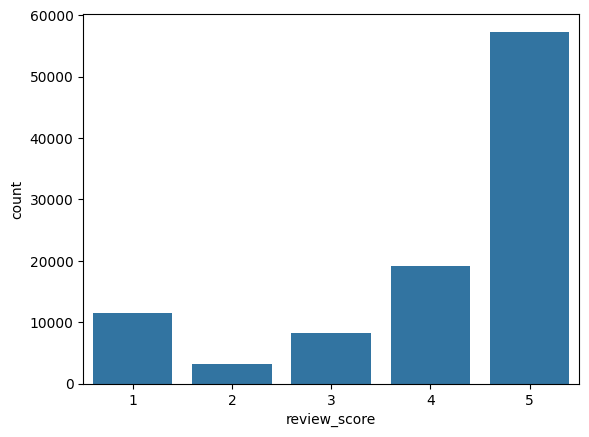

In [100]:
sns.countplot(
    data=customer_orders_reviews,
    x="review_score"
)

**Observation**

Overall customer satisfaction appears to be relatively high, with the majority of reviews receiving ratings of 4 or 5 stars. However, a notable proportion of customers assigned a review score of 1, representing the largest share among the below-average ratings.

**Interpretation**

While the overall satisfaction trend is positive, the concentration of 1-star reviews suggests that a subset of customers had particularly poor experiences. Understanding the factors contributing to these extremely negative reviews may reveal important opportunities for improving customer satisfaction and reducing customer dissatisfaction.


#### Analysis 2: Delivery Performance Overview

In [101]:
# Understanding the average time delivery takes

orders_dataset["delivery_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

### Outlier Investigation: Delivery Duration

Objective

To identify the unusually long delivery duration (about 209 days, which is the max) that may indicate data quality issues or exceptional customer experiences.

Rationale

Since this project focuses on customer satisfaction and delivery performance, unusually long delivery times may provide valuable insights into potential drivers of customer dissatisfaction.


<Axes: >

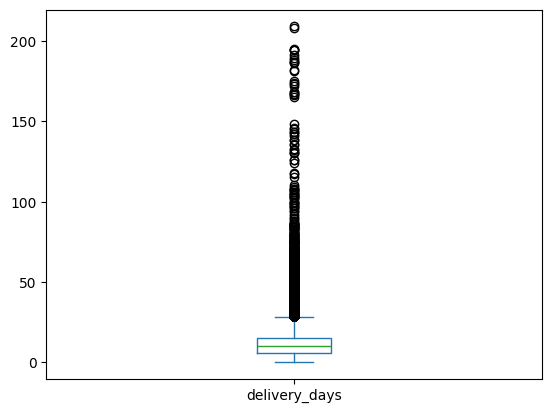

In [102]:
# Using box plots to understand the distribution of the outliers

orders_dataset["delivery_days"].plot.box()

In [103]:
# Calculating the IQR Limits

Q1 = orders_dataset["delivery_days"].quantile(0.25)
Q3 = orders_dataset["delivery_days"].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + (1.5 * IQR)

lower_limit = Q1 - (1.5 * IQR)

print(f"Lower Limit: {lower_limit}")
print(f"Upper Limit: {upper_limit}")

Lower Limit: -7.5
Upper Limit: 28.5


so anything above 28.5 should be flagged as an outlier. The Box plot shows that there are mab\

#### Exploring the relationship between the outlier delivery days and the Review scores

In [104]:
# Creating an Outlier flag using the IQR upper bound:

upper_bound = 28.5

customer_orders_reviews["delivery_outlier"] = np.where(
    customer_orders_reviews["delivery_days"] > upper_bound,
    "Outlier",
    "Normal"
)

In [105]:
(
    orders_dataset["delivery_days"] > upper_bound
).sum()

5025

In [106]:
# What percentage of the outlier delivery days influenced the review scores?
(
    
pd.crosstab(
    customer_orders_reviews["delivery_outlier"],
    customer_orders_reviews["review_score"],
    normalize="index"
) * 100
           ) .round(2)

review_score,1,2,3,4,5
delivery_outlier,,,,,
Normal,9.39,2.90,8.10,19.74,59.87
Outlier,52.11,8.51,11.04,10.72,17.62


In [107]:
# In summary, percentage of review scores affected by the delivery days (outlier or normal)

low_review_percentage = (
    pd.crosstab(
        customer_orders_reviews["delivery_outlier"],
        customer_orders_reviews["review_score"].isin([1, 2]),
        normalize="index"
    ) * 100
).round(2)

low_review_percentage.columns = [
    "Review Score 3-5",
    "Review Score 1-2"
]

low_review_percentage

,Review Score 3-5,Review Score 1-2
delivery_outlier,,
Normal,87.71,12.29
Outlier,39.38,60.62


In [108]:
# checking to see the average review scores influenced by normal or 
# outlier delivery periods

customer_orders_reviews.groupby(
    "delivery_outlier"
)["review_score"].mean().round(2)

delivery_outlier
Normal     4.18
Outlier    2.33
Name: review_score, dtype: float64

**Observation**

Orders classified as delivery outliers (i.e., orders taking 29 days or more to be delivered) received an average review score of 2.33, compared to 4.18 for orders delivered within the normal delivery range (i.e., 28 days or less). In addition, 60.62% of delivery outliers received low ratings (1–2 stars), compared to only 12.29% of normal deliveries.

**Interpretation**

This indicates a strong negative relationship between unusually long delivery times and customer satisfaction. Customers experiencing extreme delivery delays were approximately five times more likely to leave poor reviews than customers whose orders were delivered within the normal delivery range.

**Business Insight**

Delivery performance appears to be a major driver of customer satisfaction. The findings suggest that reducing extreme delivery delays could significantly improve customer ratings and overall customer experience.


#### Analysis 3: Exploring the relationship beween Review scores and Delivery Status

Question: Do customers only care about extreme delays? or Do customers react negatively whenever an order arrives after the promised date?

In [109]:
# checking for the average review score of each 'delivery_status' group

customer_orders_reviews.groupby(
    "delivery_status"
)["review_score"].mean().round(2)

delivery_status
Late             2.27
On Time/Early    4.21
Name: review_score, dtype: float64

In [110]:
delivery_status_reviews = (
    pd.crosstab(
        customer_orders_reviews["delivery_status"],
        customer_orders_reviews["review_score"].isin([1, 2]),
        normalize="index"
    ) * 100
).round(2)

delivery_status_reviews.columns = [
   "Satisfied (3-5)",
    "Dissatisfied (1-2)"
]

delivery_status_reviews

,Satisfied (3-5),Dissatisfied (1-2)
delivery_status,,
Late,37.60,62.40
On Time/Early,88.61,11.39


**Observation**

Among orders delivered on time or earlier than the estimated delivery date, only 11.39% received low ratings (1–2 stars). In contrast, 62.40% of late deliveries received low ratings.

**Interpretation**

This suggests a strong negative relationship between late deliveries and customer satisfaction. Customers whose orders arrived after the promised delivery date were more than five times as likely to leave a low review score compared to customers who received their orders on time or earlier.

**Business Insight**

Meeting delivery promises appears to be a critical driver of customer satisfaction. While extreme delivery delays significantly reduce customer ratings, the findings indicate that even ordinary late deliveries can substantially increase customer dissatisfaction. Improving delivery reliability and reducing late deliveries may therefore have a significant positive impact on customer experience.


#### Analysis 3: How Many Orders Are Late?

Question: How big is this problem of Late deliveries?

In [111]:
# Getting the percentage of orders that are late vs those on-time/early

(
    customer_orders_reviews["delivery_status"]
    .value_counts(normalize=True)
    * 100
).round(2)

delivery_status
On Time/Early    93.54
Late              6.46
Name: proportion, dtype: float64

**Observation**

The vast majority of orders (93.54%) were delivered on time or earlier than the estimated delivery date, while only 6.46% of orders were delivered late.

**Interpretation**

Although late deliveries represent a relatively small proportion of all orders, previous analyses showed that customers experiencing late deliveries were significantly more likely to leave low review scores. This suggests that customer dissatisfaction is concentrated within a relatively small subset of orders rather than being caused by a widespread delivery performance issue.

**Business Insight**

Olist's overall delivery performance appears strong; however, further reducing the proportion of late deliveries could have a disproportionately positive impact on customer satisfaction. Targeted efforts to address the causes of late deliveries may therefore provide a high return on investment in terms of customer experience.


#### Analysis 4: Severity of Delivery Delays

Questions to Answer

- What is the typical length of delivery delays for orders that arrive late?
- Are most late deliveries delayed by only a few days, or do they experience substantial delays extending into weeks?
- Is there a relationship between the severity of a delivery delay and customer satisfaction?
- At what point do delivery delays begin to have a significant impact on customer satisfaction?

In [112]:
# Descriptive Statistics for records with the delivery status of 'Late'

customer_orders_reviews.loc[
    customer_orders_reviews["delivery_status"] == "Late",
    "delivery_delay_days"
].describe()

count    6410.000000
mean       10.526833
std        14.445316
min         1.000000
25%         3.000000
50%         7.000000
75%        13.000000
max       188.000000
Name: delivery_delay_days, dtype: float64

In [113]:
# Creating bins(delay bands)for the delivery delay days for easier analysis and understanding

customer_orders_reviews["delay_band"] = pd.cut(
    customer_orders_reviews["delivery_delay_days"],
    bins=[0, 3, 7, 14, 30, 200],
    labels=[
        "1-3 Days Late",
        "4-7 Days Late",
        "8-14 Days Late",
        "15-30 Days Late",
        "30+ Days Late"
    ]
)

In [114]:
# Checking for the average review score for each delay band

customer_orders_reviews.groupby(
    "delay_band"
)["review_score"].mean().round(2)

/var/folders/pc/zvnvzl6d2rd0t5s2_v8g1y0r0000gn/T/ipykernel_32835/2418909888.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_orders_reviews.groupby(


delay_band
1-3 Days Late      3.29
4-7 Days Late      2.10
8-14 Days Late     1.68
15-30 Days Late    1.62
30+ Days Late      2.05
Name: review_score, dtype: float64

Observation

Customer satisfaction generally declined as delivery delays increased. Orders delayed by 1–3 days received an average review score of 3.29, while orders delayed by 4–7 days saw the average score drop to 2.10. Satisfaction continued to decrease for delays between 8–14 days (1.68) and 15–30 days (1.62).

Interpretation

The results suggest a strong negative relationship between the severity of delivery delays and customer satisfaction. Even relatively short delays appear to have a substantial impact on customer perceptions, with average review scores falling sharply once delays exceed three days.

Further Investigation

The average review score for orders delayed by more than 30 days (2.05) was slightly higher than for orders delayed by 15–30 days. This may be due to a smaller number of observations in the 30+ day category and should be validated by examining the distribution of orders across delay bands.


In [115]:
# Checking the order distribution across delay bands

customer_orders_reviews.groupby(
    "delay_band"
)["review_score"].count()

/var/folders/pc/zvnvzl6d2rd0t5s2_v8g1y0r0000gn/T/ipykernel_32835/2800823080.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_orders_reviews.groupby(


delay_band
1-3 Days Late      1856
4-7 Days Late      1756
8-14 Days Late     1453
15-30 Days Late    1014
30+ Days Late       331
Name: review_score, dtype: int64

The slightly higher satisfaction observed among customers experiencing delays exceeding 30 days warrants further investigation. Additional data on seller performance, customer support interactions, and product categories may help explain this pattern.

Observation

Customer satisfaction generally declined as delivery delays increased. Orders delayed by 1–3 days received an average review score of 3.29, while orders delayed by 4–7 days saw the average score drop sharply to 2.10. Satisfaction remained very low for delays of 8–14 days (1.68), 15–30 days (1.62), and 30+ days (2.05).

Interpretation

The results indicate a strong negative relationship between the severity of delivery delays and customer satisfaction. The most significant decline in satisfaction occurs once delays exceed three days, suggesting that customers are particularly sensitive to prolonged delays beyond the promised delivery date.

Business Insight

While any late delivery negatively affects customer satisfaction, preventing delays from extending beyond three days may provide the greatest opportunity to improve customer experience and review scores.


#### Also Checking the correlation coefficient

In [116]:
(
    customer_orders_reviews["delivery_delay_days"].corr(
    customer_orders_reviews["review_score"]
)
).round(3)

-0.267

Observation

A correlation analysis between delivery delay days and review scores produced a correlation coefficient of -0.267.

Interpretation

The negative coefficient indicates that customer satisfaction tends to decrease as delivery delays increase. However, the relationship is relatively weak, suggesting that delivery performance is only one of several factors influencing customer satisfaction.

Business Insight

While delivery delays are associated with lower customer ratings, other factors such as product quality, seller performance, customer service, and order fulfillment may also play important roles in shaping the overall customer experience. Further investigation into these factors may provide additional opportunities for improving customer satisfaction.


#### Updating Customer State Data

In [117]:
customer_orders_reviews["customer_state"].unique()

array(['SP', 'SC', 'MG', 'PR', 'RJ', 'RS', 'PA', 'GO', 'ES', 'BA', 'MA',
       'MS', 'CE', 'DF', 'RN', 'PE', 'MT', 'AM', 'AP', 'AL', 'RO', 'PB',
       'TO', 'PI', 'AC', 'SE', 'RR'], dtype=object)

In [118]:
# Adding a new column with the full name of the customer states

# From the Olist documentation, it's based off a Brazillian e-commerce store and the state 
# abbreviations are the standard abbreviations for Brazillian states.

state_mapping = {
    "AC": "Acre",
    "AL": "Alagoas",
    "AP": "Amapá",
    "AM": "Amazonas",
    "BA": "Bahia",
    "CE": "Ceará",
    "DF": "Distrito Federal",
    "ES": "Espírito Santo",
    "GO": "Goiás",
    "MA": "Maranhão",
    "MT": "Mato Grosso",
    "MS": "Mato Grosso do Sul",
    "MG": "Minas Gerais",
    "PA": "Pará",
    "PB": "Paraíba",
    "PR": "Paraná",
    "PE": "Pernambuco",
    "PI": "Piauí",
    "RJ": "Rio de Janeiro",
    "RN": "Rio Grande do Norte",
    "RS": "Rio Grande do Sul",
    "RO": "Rondônia",
    "RR": "Roraima",
    "SC": "Santa Catarina",
    "SP": "São Paulo",
    "SE": "Sergipe",
    "TO": "Tocantins"
}

customer_orders_reviews["customer_state_name"] = (
    customer_orders_reviews["customer_state"]
    .map(state_mapping)
)



In [119]:
customer_orders_reviews["customer_state_name"].unique()

array(['São Paulo', 'Santa Catarina', 'Minas Gerais', 'Paraná',
       'Rio de Janeiro', 'Rio Grande do Sul', 'Pará', 'Goiás',
       'Espírito Santo', 'Bahia', 'Maranhão', 'Mato Grosso do Sul',
       'Ceará', 'Distrito Federal', 'Rio Grande do Norte', 'Pernambuco',
       'Mato Grosso', 'Amazonas', 'Amapá', 'Alagoas', 'Rondônia',
       'Paraíba', 'Tocantins', 'Piauí', 'Acre', 'Sergipe', 'Roraima'],
      dtype=object)

#### Creating the Tableau dataset

In [120]:
tableau_dataset = customer_orders_reviews[
    [
        "order_id",
        "customer_unique_id",
        "review_score",
        "delivery_days",
        "delivery_delay_days",
        "delivery_status",
        "delivery_outlier",
        "delay_band",
        "customer_state_name",
        "order_purchase_timestamp"
    ]
].copy()

In [121]:
# adding another column to the Tableau dataset ie the country column to help with Geographical
# visualizations

tableau_dataset["country"] = "Brazil"

In [122]:
tableau_dataset.head()

,order_id,customer_unique_id,review_score,delivery_days,delivery_delay_days,delivery_status,delivery_outlier,delay_band,customer_state_name,order_purchase_timestamp,country
0,00e7ee1b050b8499577073aeb2a297a1,861eff4711a542e4b93843c6dd7febb0,4,8.0,-11.0,On Time/Early,Normal,NaN,São Paulo,2017-05-16 15:05:35,Brazil
1,29150127e6685892b6eab3eec79f59c7,290c77bc529b7ac935b93aa66c333dc3,5,16.0,-8.0,On Time/Early,Normal,NaN,São Paulo,2018-01-12 20:48:24,Brazil
2,b2059ed67ce144a36e2aa97d2c9e9ad2,060e732b5b29e8181a18229c7b0b2b5e,5,26.0,1.0,Late,Normal,1-3 Days Late,São Paulo,2018-05-19 16:07:45,Brazil
3,951670f92359f4fe4a63112aa7306eba,259dac757896d24d7702b9acbbff3f3c,5,14.0,-13.0,On Time/Early,Normal,NaN,São Paulo,2018-03-13 16:06:38,Brazil
4,6b7d50bd145f6fc7f33cebabd7e49d0f,345ecd01c38d18a9036ed96c73b8d066,5,11.0,-6.0,On Time/Early,Normal,NaN,São Paulo,2018-07-29 09:51:30,Brazil


In [123]:
tableau_dataset.shape

(99224, 11)

In [124]:
tableau_dataset.to_csv(
    "olist_customer_satisfaction_analysis.csv",
    index=False
)

In [125]:
tableau_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   order_id                  99224 non-null  object        
 1   customer_unique_id        99224 non-null  object        
 2   review_score              99224 non-null  int64         
 3   delivery_days             96359 non-null  float64       
 4   delivery_delay_days       96359 non-null  float64       
 5   delivery_status           99224 non-null  object        
 6   delivery_outlier          99224 non-null  object        
 7   delay_band                6410 non-null   category      
 8   customer_state_name       99224 non-null  object        
 9   order_purchase_timestamp  99224 non-null  datetime64[ns]
 10  country                   99224 non-null  object        
dtypes: category(1), datetime64[ns](1), float64(2), int64(1), object(6)
memory usage:

In [126]:
import os

os.getcwd()

'/Users/mac/Documents/Data science:analytics projects/Chidiogo_Ezeugwu_Capstone Project'